# Разведочный анализ данных (EDA)
## ВКР: прогнозирование свойств композиционных материалов

Блок 1 выпускной квалификационной работы. В этом ноутбуке выполняется:

1. Загрузка и объединение исходных данных.
2. Описательная статистика.
3. Визуализация распределений и корреляций.
4. Поиск и удаление выбросов методом IQR.
5. Нормализация признаков (MinMaxScaler).
6. Сохранение очищенного и нормализованного датасетов.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

FIGURES_DIR = "../figures"
DATA_DIR = "../data"
PROCESSED_DIR = "../data/processed"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


## 1. Загрузка и объединение данных

Загружаем два файла: `X_bp.xlsx` содержит параметры композита и его
компонентов (связующего и наполнителя), `X_nup.xlsx` содержит параметры
нашивки (угол нашивки, шаг нашивки, плотность нашивки). Первый столбец в
каждом файле — индекс образца (`index_col=0`). Объединяем таблицы по индексу
через **INNER JOIN**, чтобы оставить только образцы, присутствующие в обоих
файлах.

In [2]:
df_bp = pd.read_excel(os.path.join(DATA_DIR, "X_bp.xlsx"), index_col=0)
df_nup = pd.read_excel(os.path.join(DATA_DIR, "X_nup.xlsx"), index_col=0)

print("X_bp.xlsx  shape:", df_bp.shape)
print("X_nup.xlsx shape:", df_nup.shape)

df = df_bp.join(df_nup, how="inner")
print("Объединённый датасет (INNER JOIN) shape:", df.shape)
df.head()


X_bp.xlsx  shape: (1023, 10)
X_nup.xlsx shape: (1040, 3)
Объединённый датасет (INNER JOIN) shape: (1023, 13)


,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,1.857143,2030.0,738.736842,30.00,22.267857,100.000000,210.0,70.0,3000.0,220.0,0,4.0,57.0
1,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,60.0
2,1.857143,2030.0,738.736842,49.90,33.000000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,70.0
3,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.0,3000.0,220.0,0,5.0,47.0
4,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,57.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Соотношение матрица-наполнитель       1023 non-null   float64
 1   Плотность, кг/м3                      1023 non-null   float64
 2   модуль упругости, ГПа                 1023 non-null   float64
 3   Количество отвердителя, м.%           1023 non-null   float64
 4   Содержание эпоксидных групп,%_2       1023 non-null   float64
 5   Температура вспышки, С_2              1023 non-null   float64
 6   Поверхностная плотность, г/м2         1023 non-null   float64
 7   Модуль упругости при растяжении, ГПа  1023 non-null   float64
 8   Прочность при растяжении, МПа         1023 non-null   float64
 9   Потребление смолы, г/м2               1023 non-null   float64
 10  Угол нашивки, град                    1023 non-null   int64  
 11  Шаг нашивки                 

### Типы данных, пропуски и дубликаты

In [4]:
dtypes_table = df.dtypes.rename("Тип данных").to_frame()
display(dtypes_table)

missing = df.isnull().sum().rename("Количество пропусков").to_frame()
missing["Доля пропусков, %"] = (missing["Количество пропусков"] / len(df) * 100).round(2)
display(missing)

n_duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов строк: {n_duplicates}")
print(f"Итоговый размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")


,Тип данных
Соотношение матрица-наполнитель,float64
"Плотность, кг/м3",float64
"модуль упругости, ГПа",float64
"Количество отвердителя, м.%",float64
"Содержание эпоксидных групп,%_2",float64
"Температура вспышки, С_2",float64
"Поверхностная плотность, г/м2",float64
"Модуль упругости при растяжении, ГПа",float64
"Прочность при растяжении, МПа",float64
"Потребление смолы, г/м2",float64


,Количество пропусков,"Доля пропусков, %"
Соотношение матрица-наполнитель,0,0.0
"Плотность, кг/м3",0,0.0
"модуль упругости, ГПа",0,0.0
"Количество отвердителя, м.%",0,0.0
"Содержание эпоксидных групп,%_2",0,0.0
"Температура вспышки, С_2",0,0.0
"Поверхностная плотность, г/м2",0,0.0
"Модуль упругости при растяжении, ГПа",0,0.0
"Прочность при растяжении, МПа",0,0.0
"Потребление смолы, г/м2",0,0.0


Количество полных дубликатов строк: 0
Итоговый размер датасета: 1023 строк, 13 столбцов


## 2. Описательная статистика

Для каждого из 13 признаков рассчитываем среднее, медиану, стандартное
отклонение, минимум, максимум и квартили. Таблица сохраняется в
`figures/descriptive_stats.csv`.

In [5]:
desc = df.describe().T
desc["медиана"] = df.median()
desc = desc.rename(columns={
    "count": "количество",
    "mean": "среднее",
    "std": "стд. отклонение",
    "min": "минимум",
    "25%": "25-й перцентиль",
    "50%": "50-й перцентиль (медиана, дубль)",
    "75%": "75-й перцентиль",
    "max": "максимум",
})
desc = desc[["количество", "среднее", "медиана", "стд. отклонение",
             "минимум", "25-й перцентиль", "75-й перцентиль", "максимум"]]

desc.to_csv(os.path.join(FIGURES_DIR, "descriptive_stats.csv"), encoding="utf-8-sig")
desc


,количество,среднее,медиана,стд. отклонение,минимум,25-й перцентиль,75-й перцентиль,максимум
Соотношение матрица-наполнитель,1023.0,2.930366,2.906878,0.913222,0.389403,2.317887,3.552660,5.591742
"Плотность, кг/м3",1023.0,1975.734888,1977.621657,73.729231,1731.764635,1924.155467,2021.374375,2207.773481
"модуль упругости, ГПа",1023.0,739.923233,739.664328,330.231581,2.436909,500.047452,961.812526,1911.536477
"Количество отвердителя, м.%",1023.0,110.570769,110.564840,28.295911,17.740275,92.443497,129.730366,198.953207
"Содержание эпоксидных групп,%_2",1023.0,22.244390,22.230744,2.406301,14.254985,20.608034,23.961934,33.000000
"Температура вспышки, С_2",1023.0,285.882151,285.896812,40.943260,100.000000,259.066528,313.002106,413.273418
"Поверхностная плотность, г/м2",1023.0,482.731833,451.864365,281.314690,0.603740,266.816645,693.225017,1399.542362
"Модуль упругости при растяжении, ГПа",1023.0,73.328571,73.268805,3.118983,64.054061,71.245018,75.356612,82.682051
"Прочность при растяжении, МПа",1023.0,2466.922843,2459.524526,485.628006,1036.856605,2135.850448,2767.193119,3848.436732
"Потребление смолы, г/м2",1023.0,218.423144,219.198882,59.735931,33.803026,179.627520,257.481724,414.590628


## 3. Визуализация данных

### 3.1 Гистограммы с KDE

Для каждой из 13 переменных строим гистограмму распределения с наложенной
кривой плотности (KDE), чтобы оценить форму распределения и наличие
асимметрии.

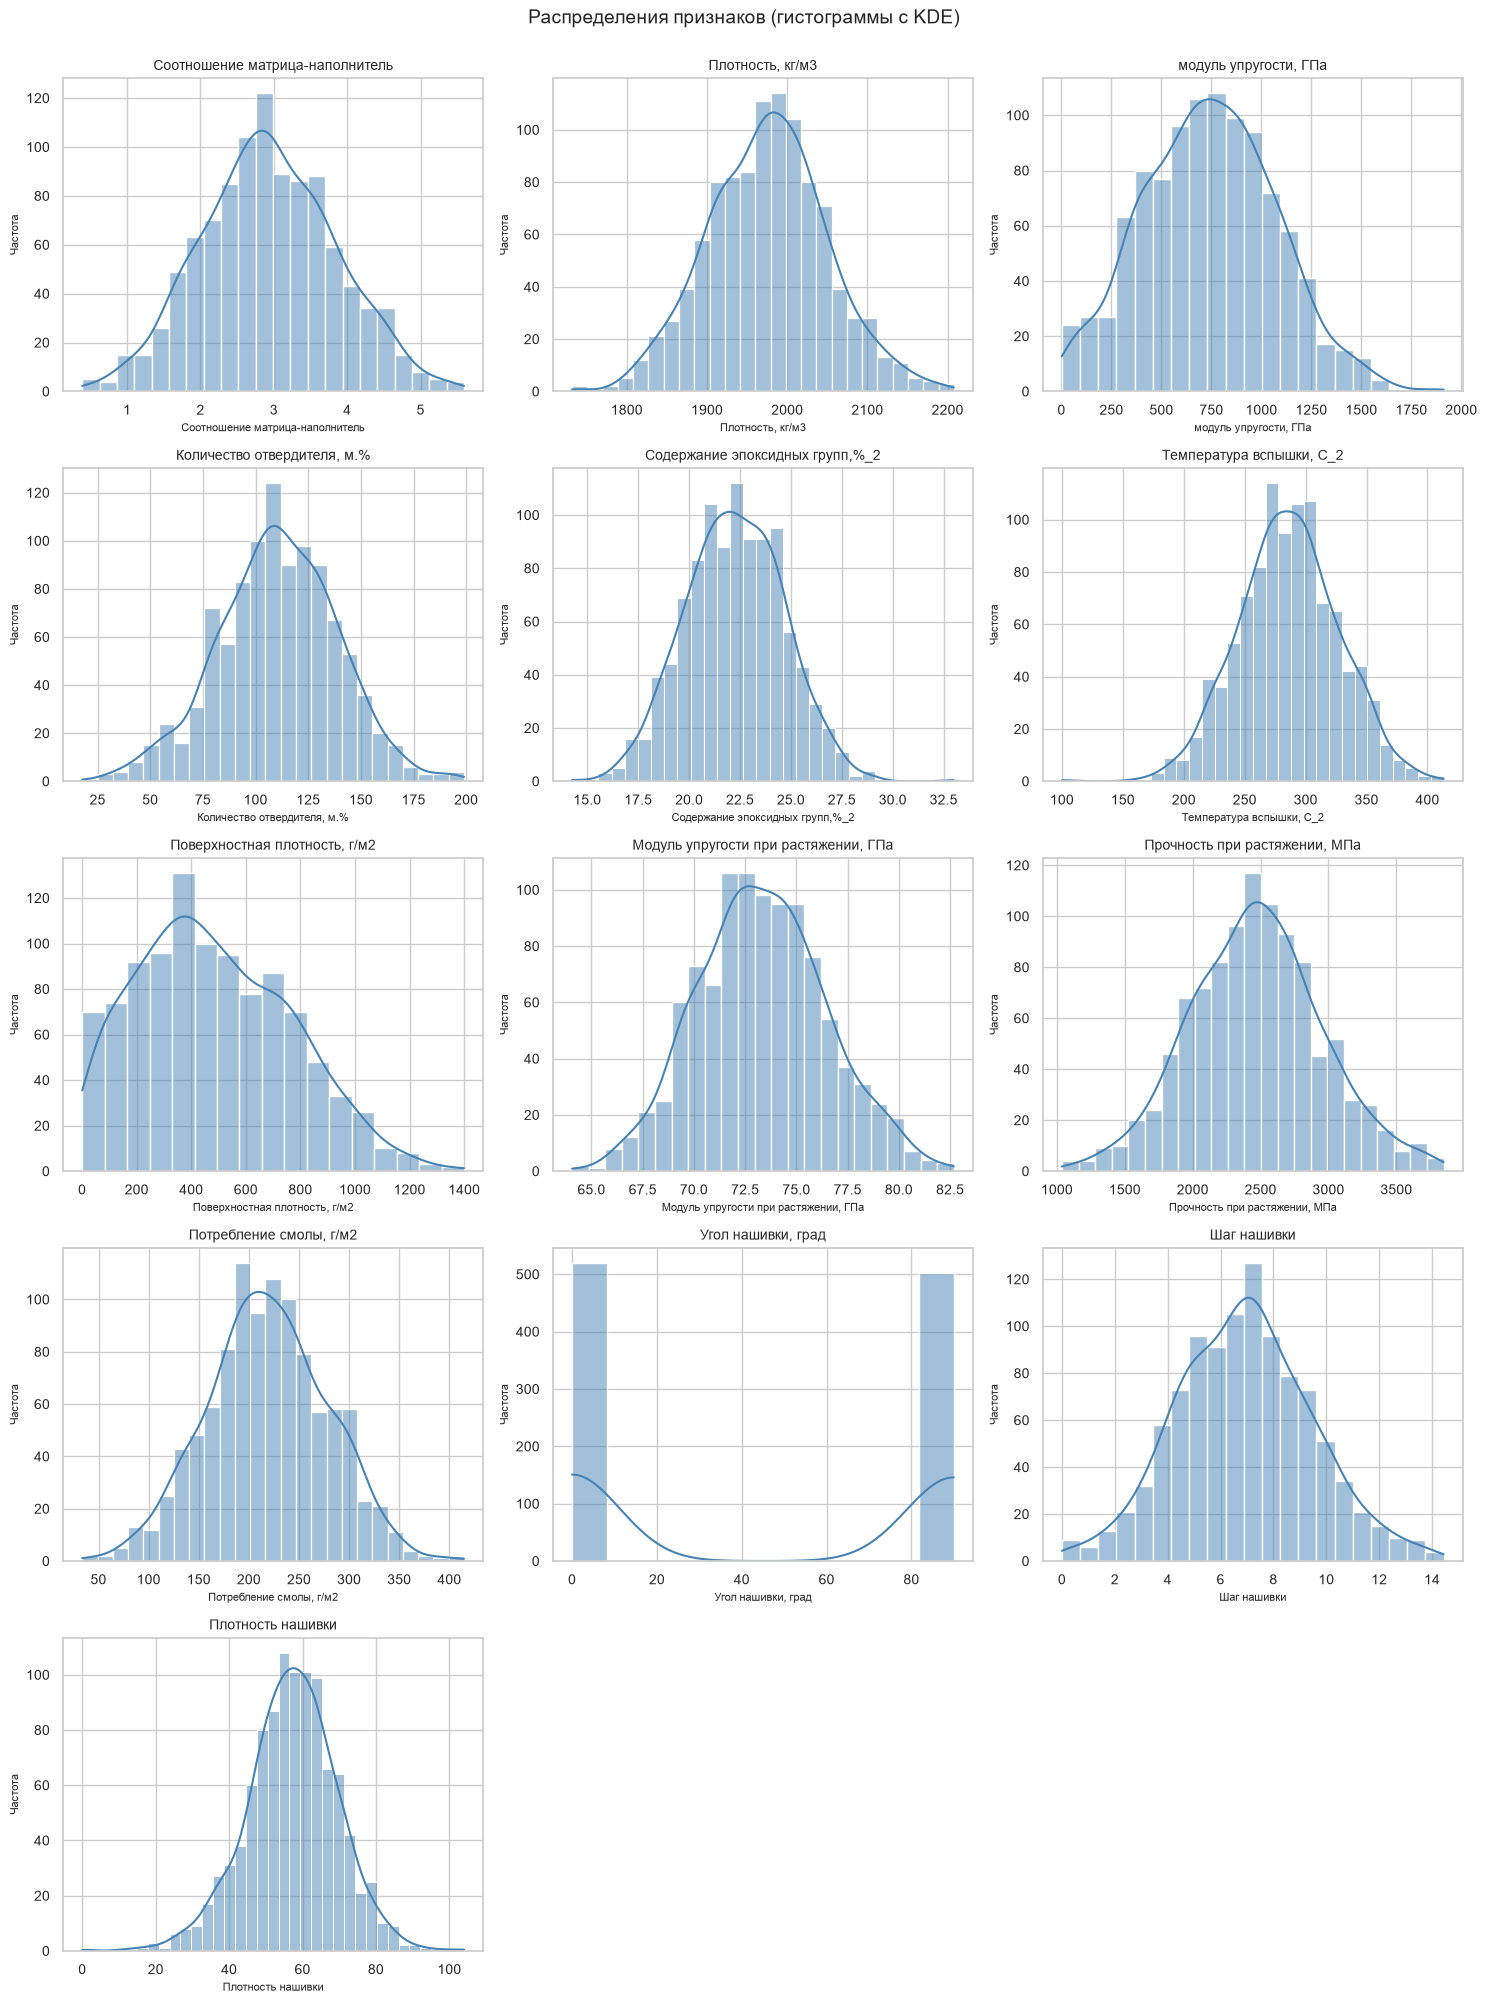

In [6]:
cols = df.columns.tolist()
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel("Частота", fontsize=8)

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Распределения признаков (гистограммы с KDE)", fontsize=14, y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "histograms_kde.png"), dpi=300, bbox_inches="tight")
plt.show()


### 3.2 Boxplot-ы (диаграммы размаха)

Диаграммы размаха помогают визуально оценить разброс значений и наличие
потенциальных выбросов по каждому признаку.

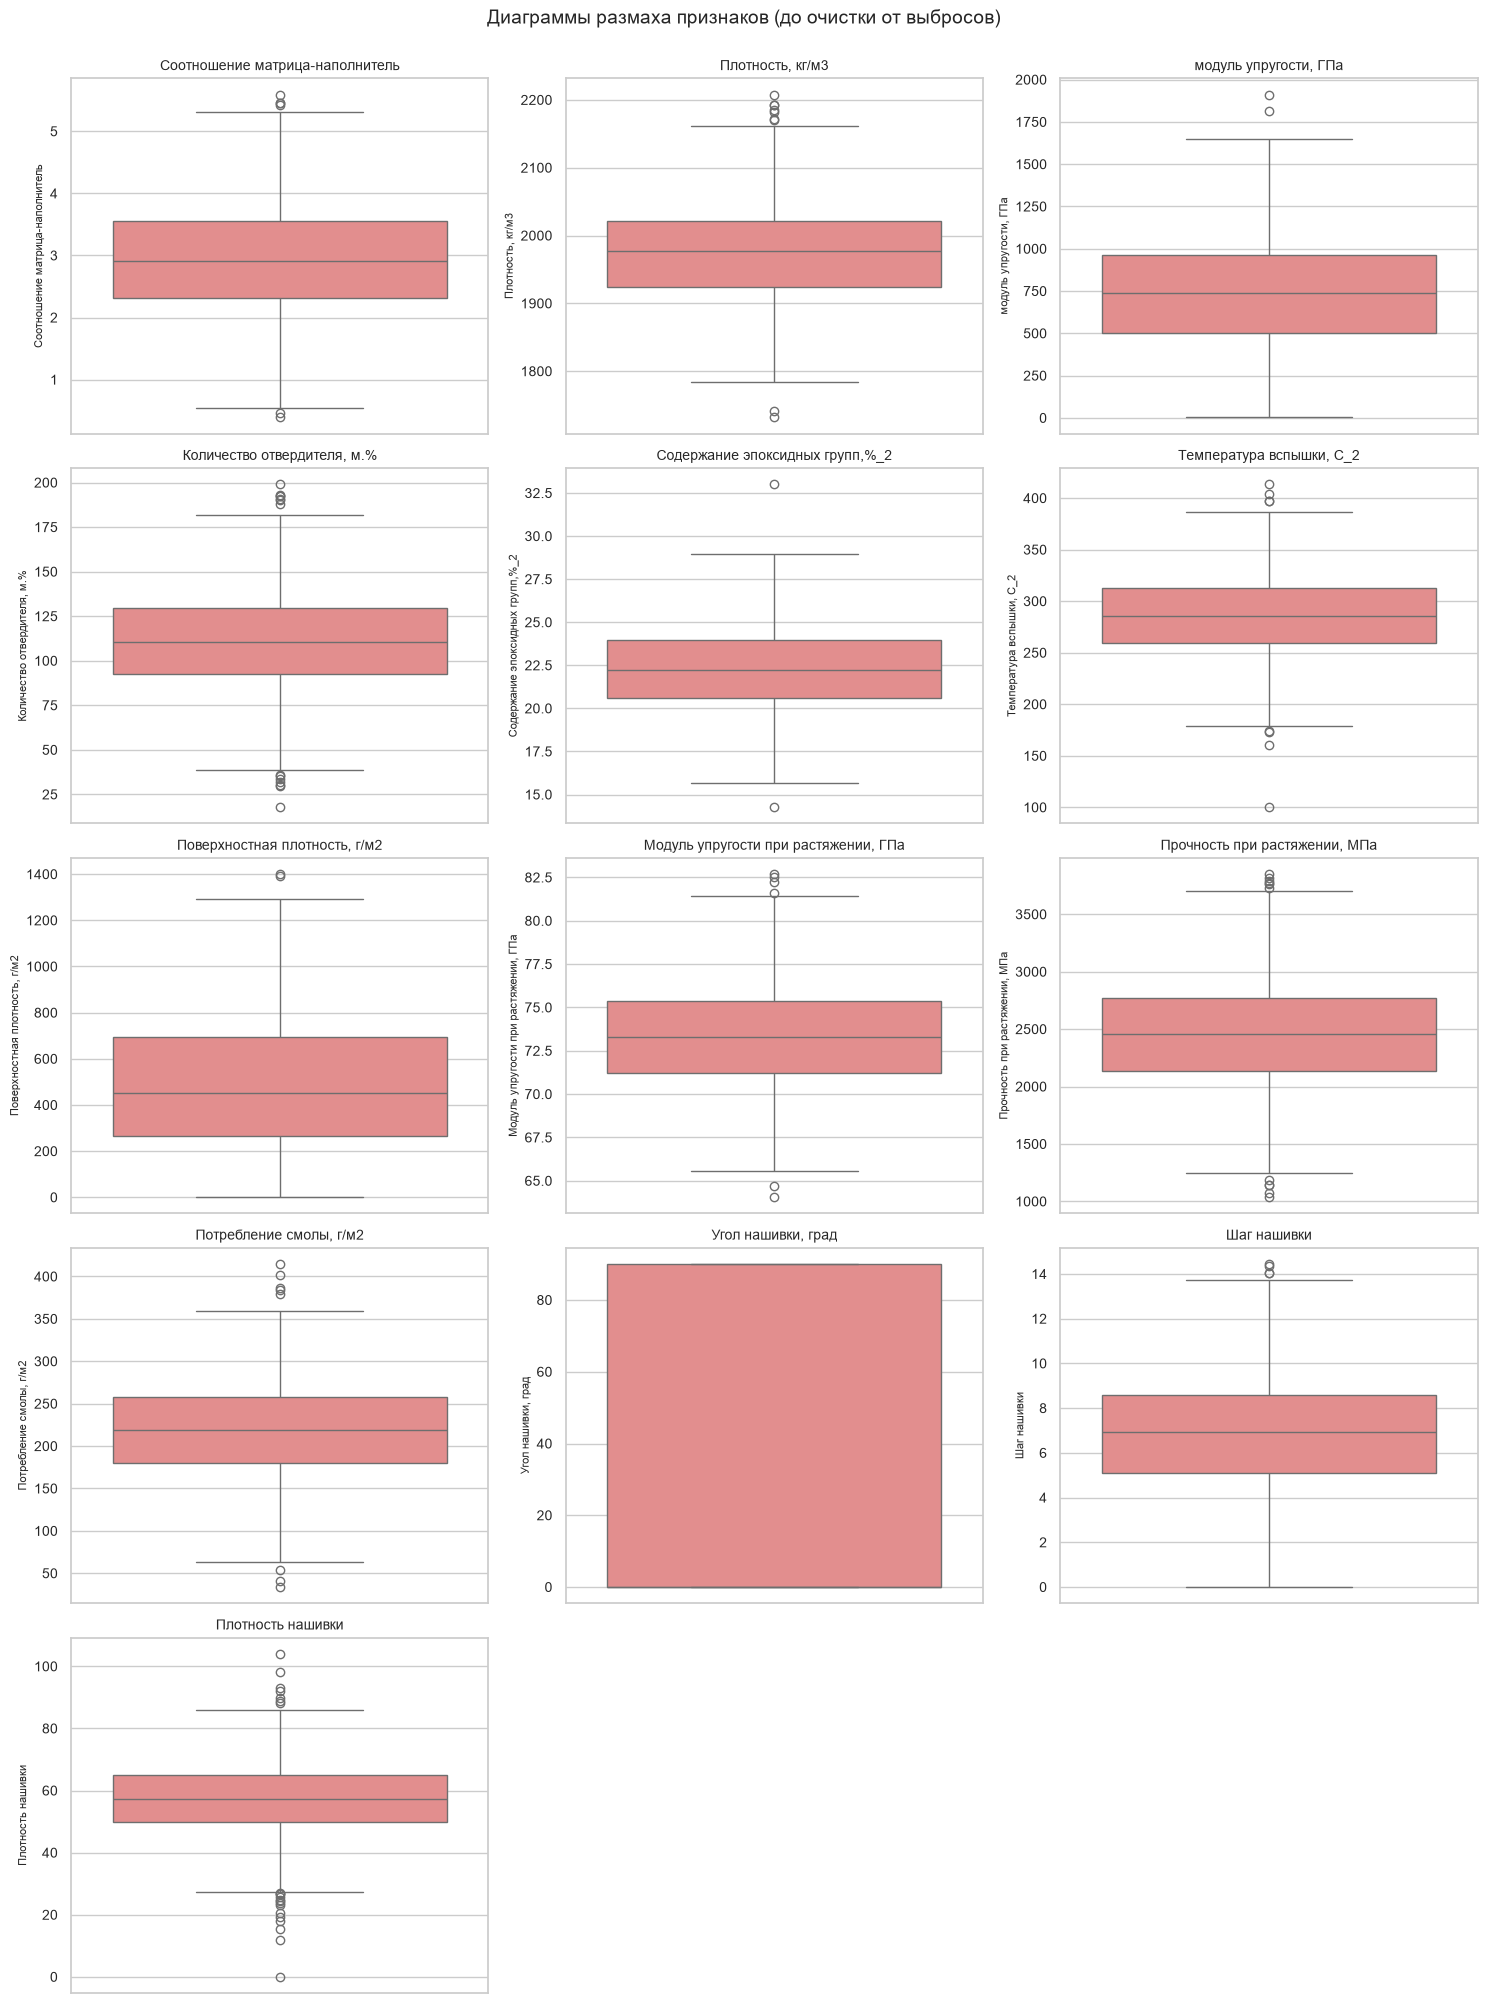

In [7]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel(col, fontsize=8)

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Диаграммы размаха признаков (до очистки от выбросов)", fontsize=14, y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "boxplots_before_cleaning.png"), dpi=300, bbox_inches="tight")
plt.show()


### 3.3 Pairplot (диаграммы рассеяния по парам признаков)

Матрица диаграмм рассеяния показывает взаимосвязи между всеми парами
признаков одновременно.

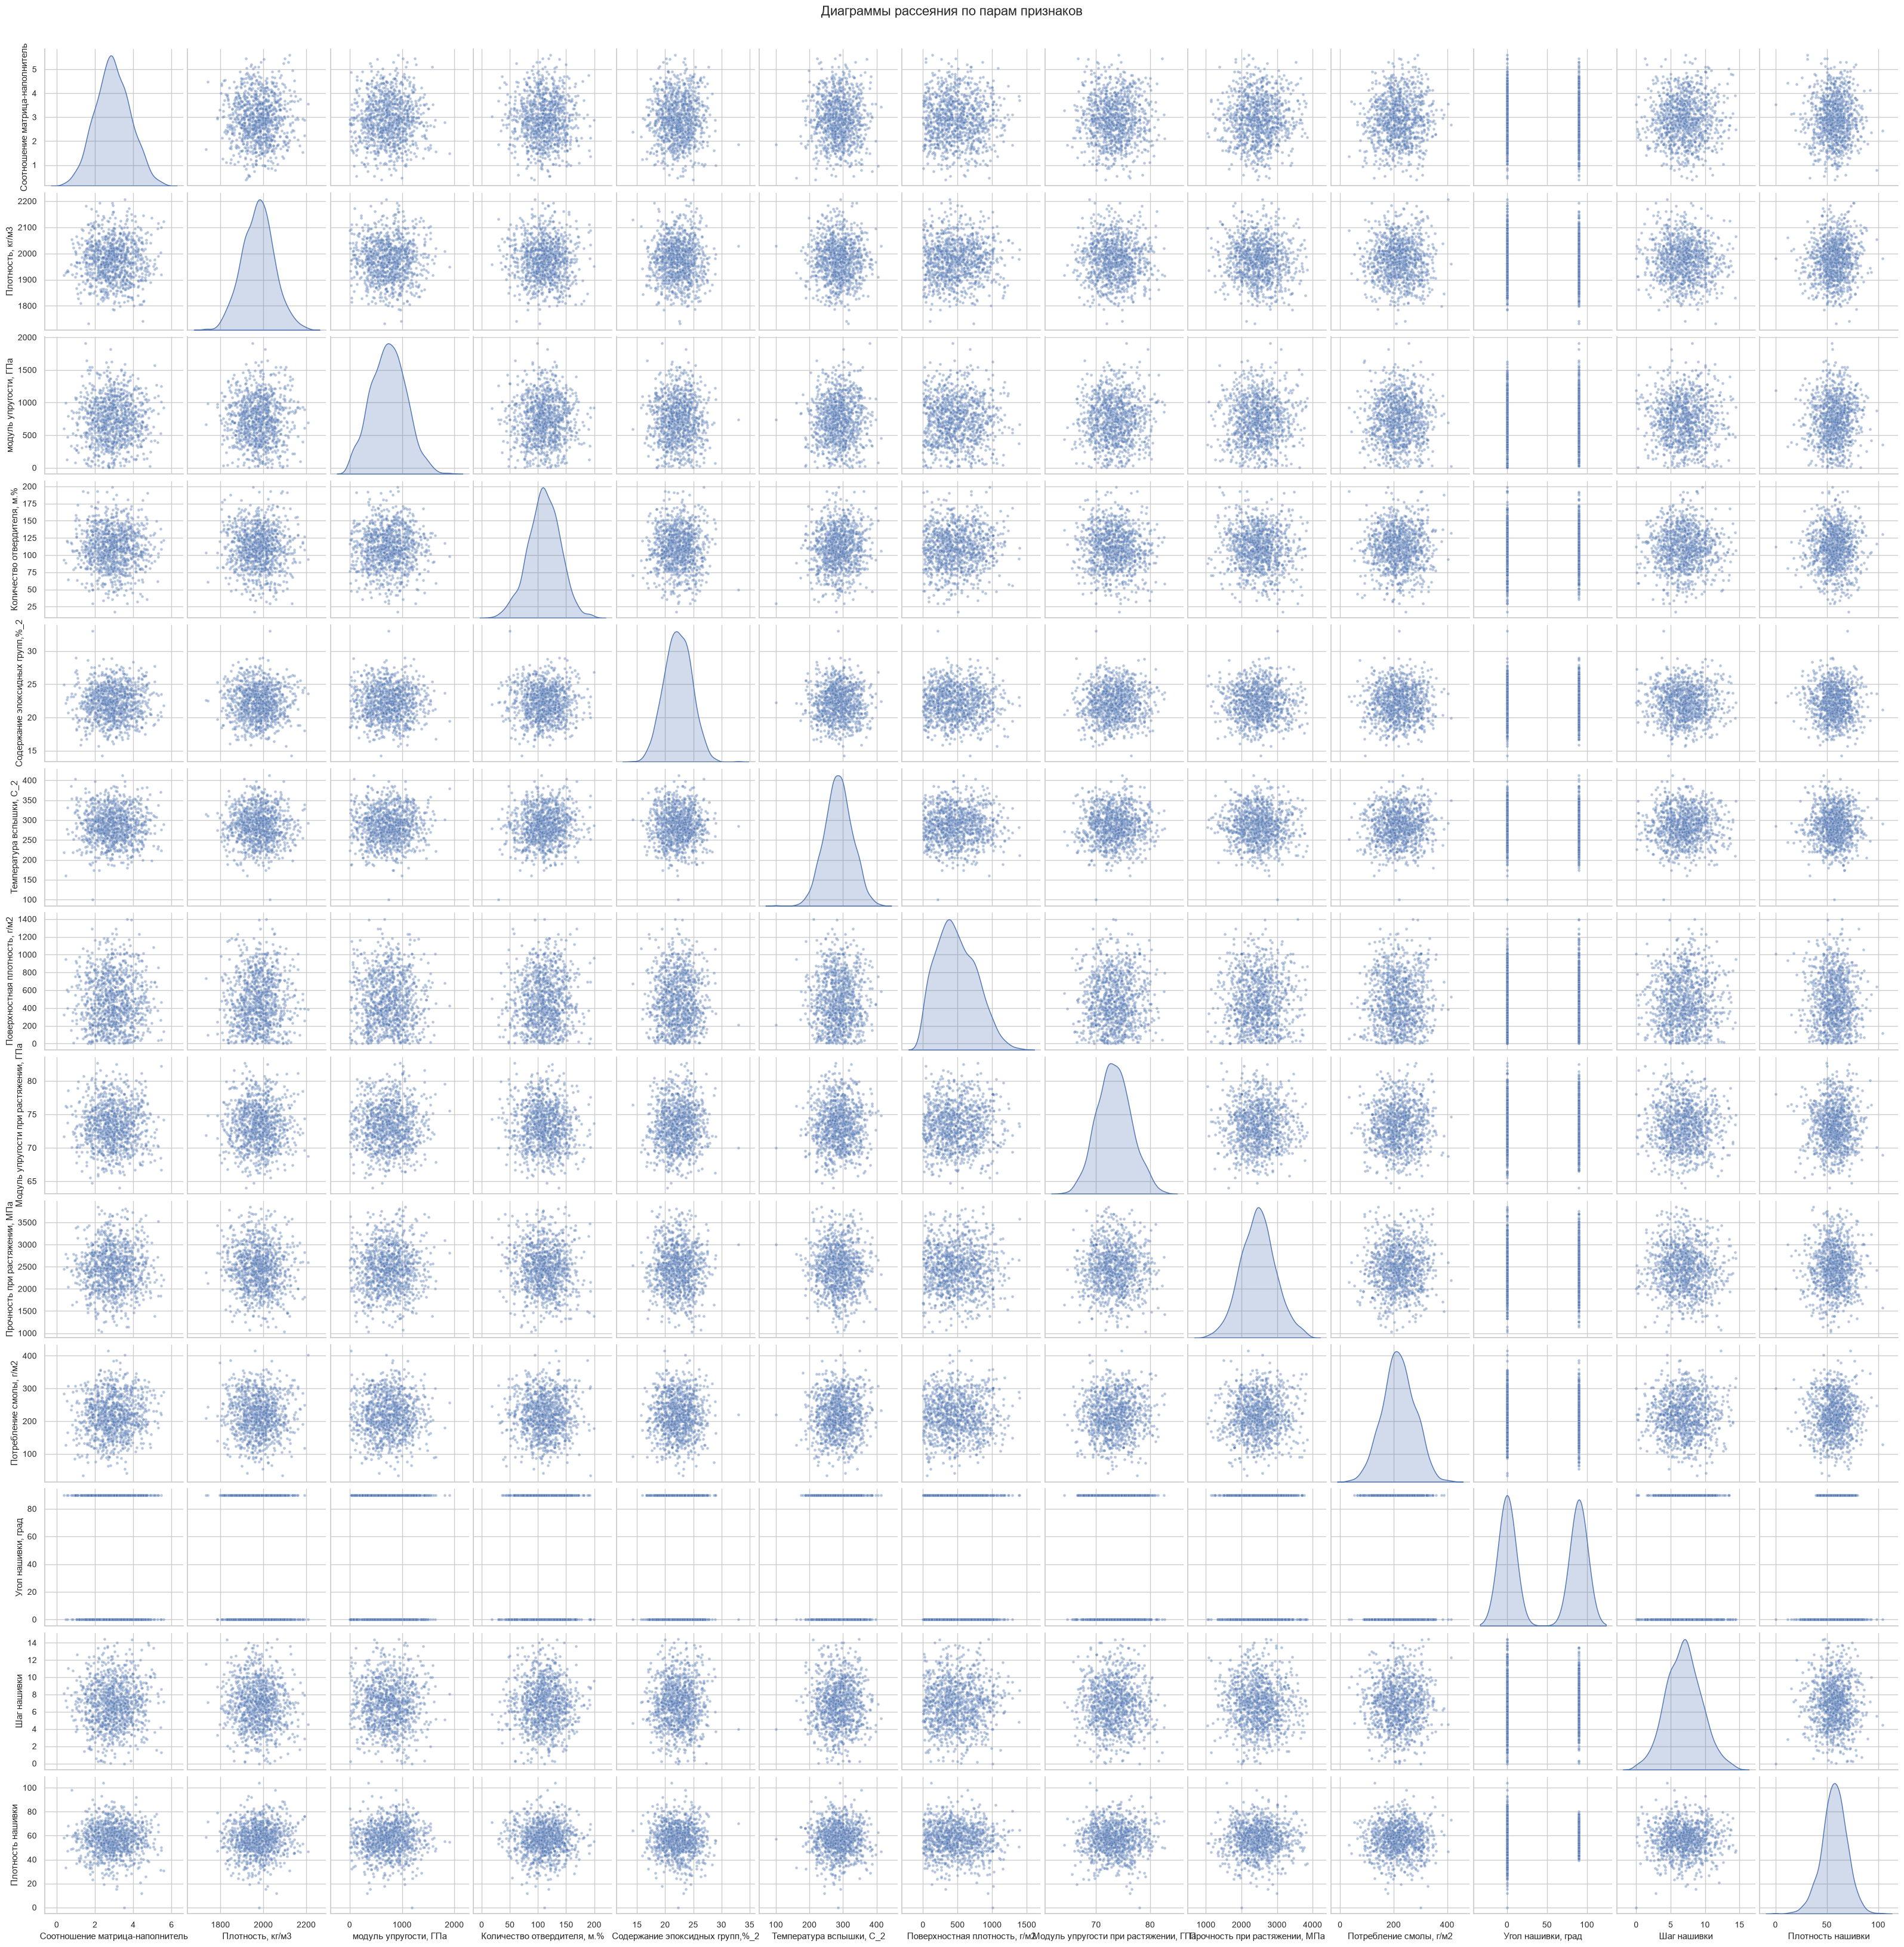

In [8]:
pairplot = sns.pairplot(df, diag_kind="kde", plot_kws={"alpha": 0.4, "s": 12})
pairplot.fig.suptitle("Диаграммы рассеяния по парам признаков", y=1.01, fontsize=16)
pairplot.savefig(os.path.join(FIGURES_DIR, "pairplot.png"), dpi=300, bbox_inches="tight")
plt.show()


### 3.4 Тепловая карта корреляций

Матрица корреляций Пирсона между всеми числовыми признаками.

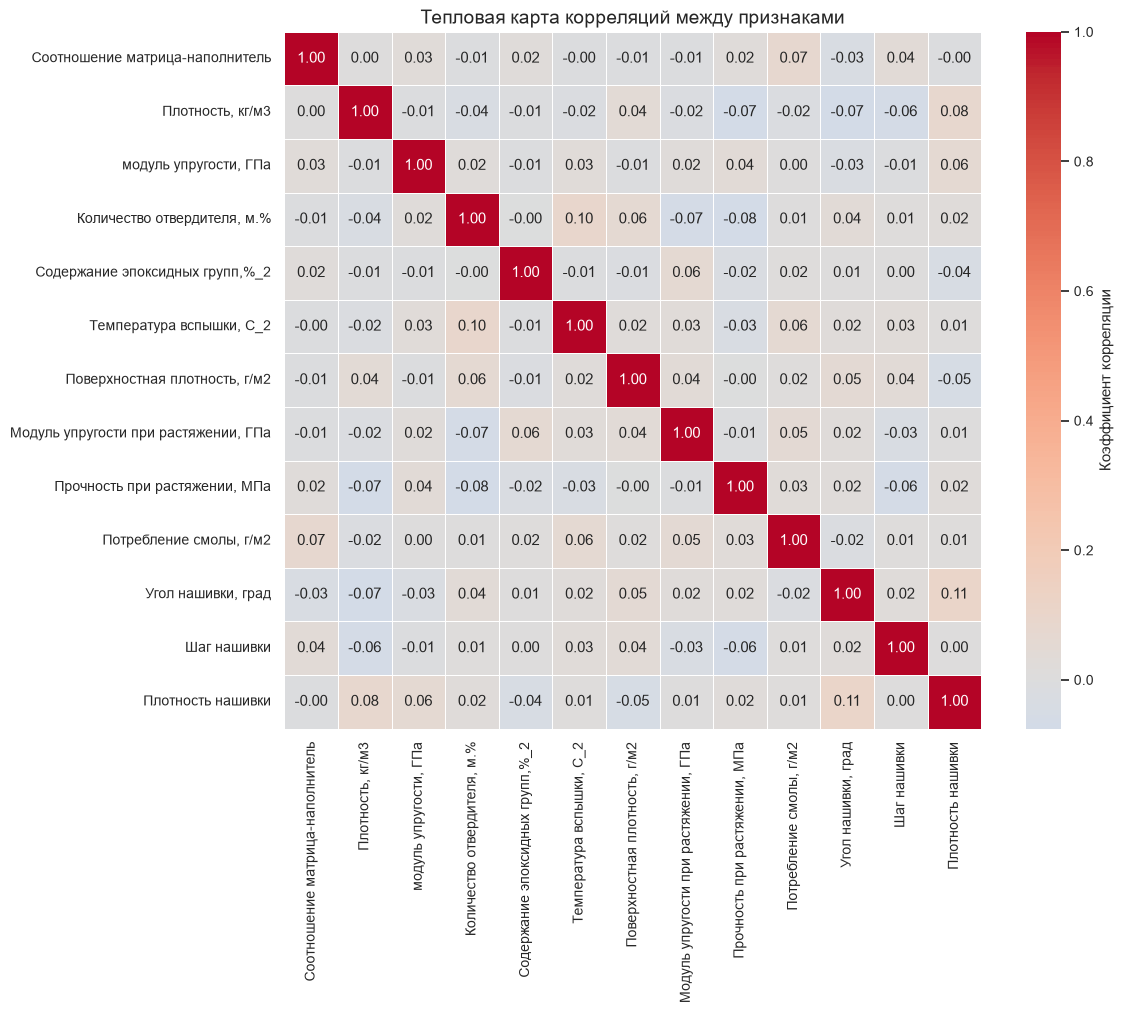

In [9]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Коэффициент корреляции"}, ax=ax)
ax.set_title("Тепловая карта корреляций между признаками", fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "correlation_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()


In [10]:
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
corr_pairs = corr_pairs.sort_values(key=lambda s: s.abs(), ascending=False)
print("Топ-10 пар признаков по модулю коэффициента корреляции:")
corr_pairs.head(10)


Топ-10 пар признаков по модулю коэффициента корреляции:


Угол нашивки, град               Плотность нашивки                       0.107947
Количество отвердителя, м.%      Температура вспышки, С_2                0.095193
Плотность, кг/м3                 Плотность нашивки                       0.080304
Количество отвердителя, м.%      Прочность при растяжении, МПа          -0.075375
Соотношение матрица-наполнитель  Потребление смолы, г/м2                 0.072531
Плотность, кг/м3                 Прочность при растяжении, МПа          -0.069981
                                 Угол нашивки, град                     -0.068474
Количество отвердителя, м.%      Модуль упругости при растяжении, ГПа   -0.065929
Плотность, кг/м3                 Шаг нашивки                            -0.061015
Температура вспышки, С_2         Потребление смолы, г/м2                 0.059954
dtype: float64

## 4. Поиск и удаление выбросов методом IQR

Для каждого признака вычисляем межквартильный размах
IQR = Q3 - Q1 и границы выбросов:

- нижняя граница: Q1 - 1.5 * IQR
- верхняя граница: Q3 + 1.5 * IQR

Значения за пределами границ считаются выбросами. Строка удаляется из
датасета, если хотя бы один признак в ней является выбросом.

In [11]:
outlier_counts = {}
outlier_mask_total = pd.Series(False, index=df.index)

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    col_mask = (df[col] < lower) | (df[col] > upper)
    outlier_counts[col] = int(col_mask.sum())
    outlier_mask_total |= col_mask

outliers_table = pd.Series(outlier_counts, name="Количество выбросов").to_frame()
outliers_table["Доля от выборки, %"] = (outliers_table["Количество выбросов"] / len(df) * 100).round(2)
display(outliers_table)

n_rows_to_remove = int(outlier_mask_total.sum())
print(f"Строк с хотя бы одним выбросом: {n_rows_to_remove}")
print(f"Размер датасета до очистки: {df.shape}")

df_clean = df.loc[~outlier_mask_total].copy()
print(f"Размер датасета после очистки: {df_clean.shape}")


,Количество выбросов,"Доля от выборки, %"
Соотношение матрица-наполнитель,6,0.59
"Плотность, кг/м3",9,0.88
"модуль упругости, ГПа",2,0.20
"Количество отвердителя, м.%",14,1.37
"Содержание эпоксидных групп,%_2",2,0.20
"Температура вспышки, С_2",8,0.78
"Поверхностная плотность, г/м2",2,0.20
"Модуль упругости при растяжении, ГПа",6,0.59
"Прочность при растяжении, МПа",11,1.08
"Потребление смолы, г/м2",8,0.78


Строк с хотя бы одним выбросом: 87
Размер датасета до очистки: (1023, 13)
Размер датасета после очистки: (936, 13)


### Диаграммы размаха после очистки от выбросов

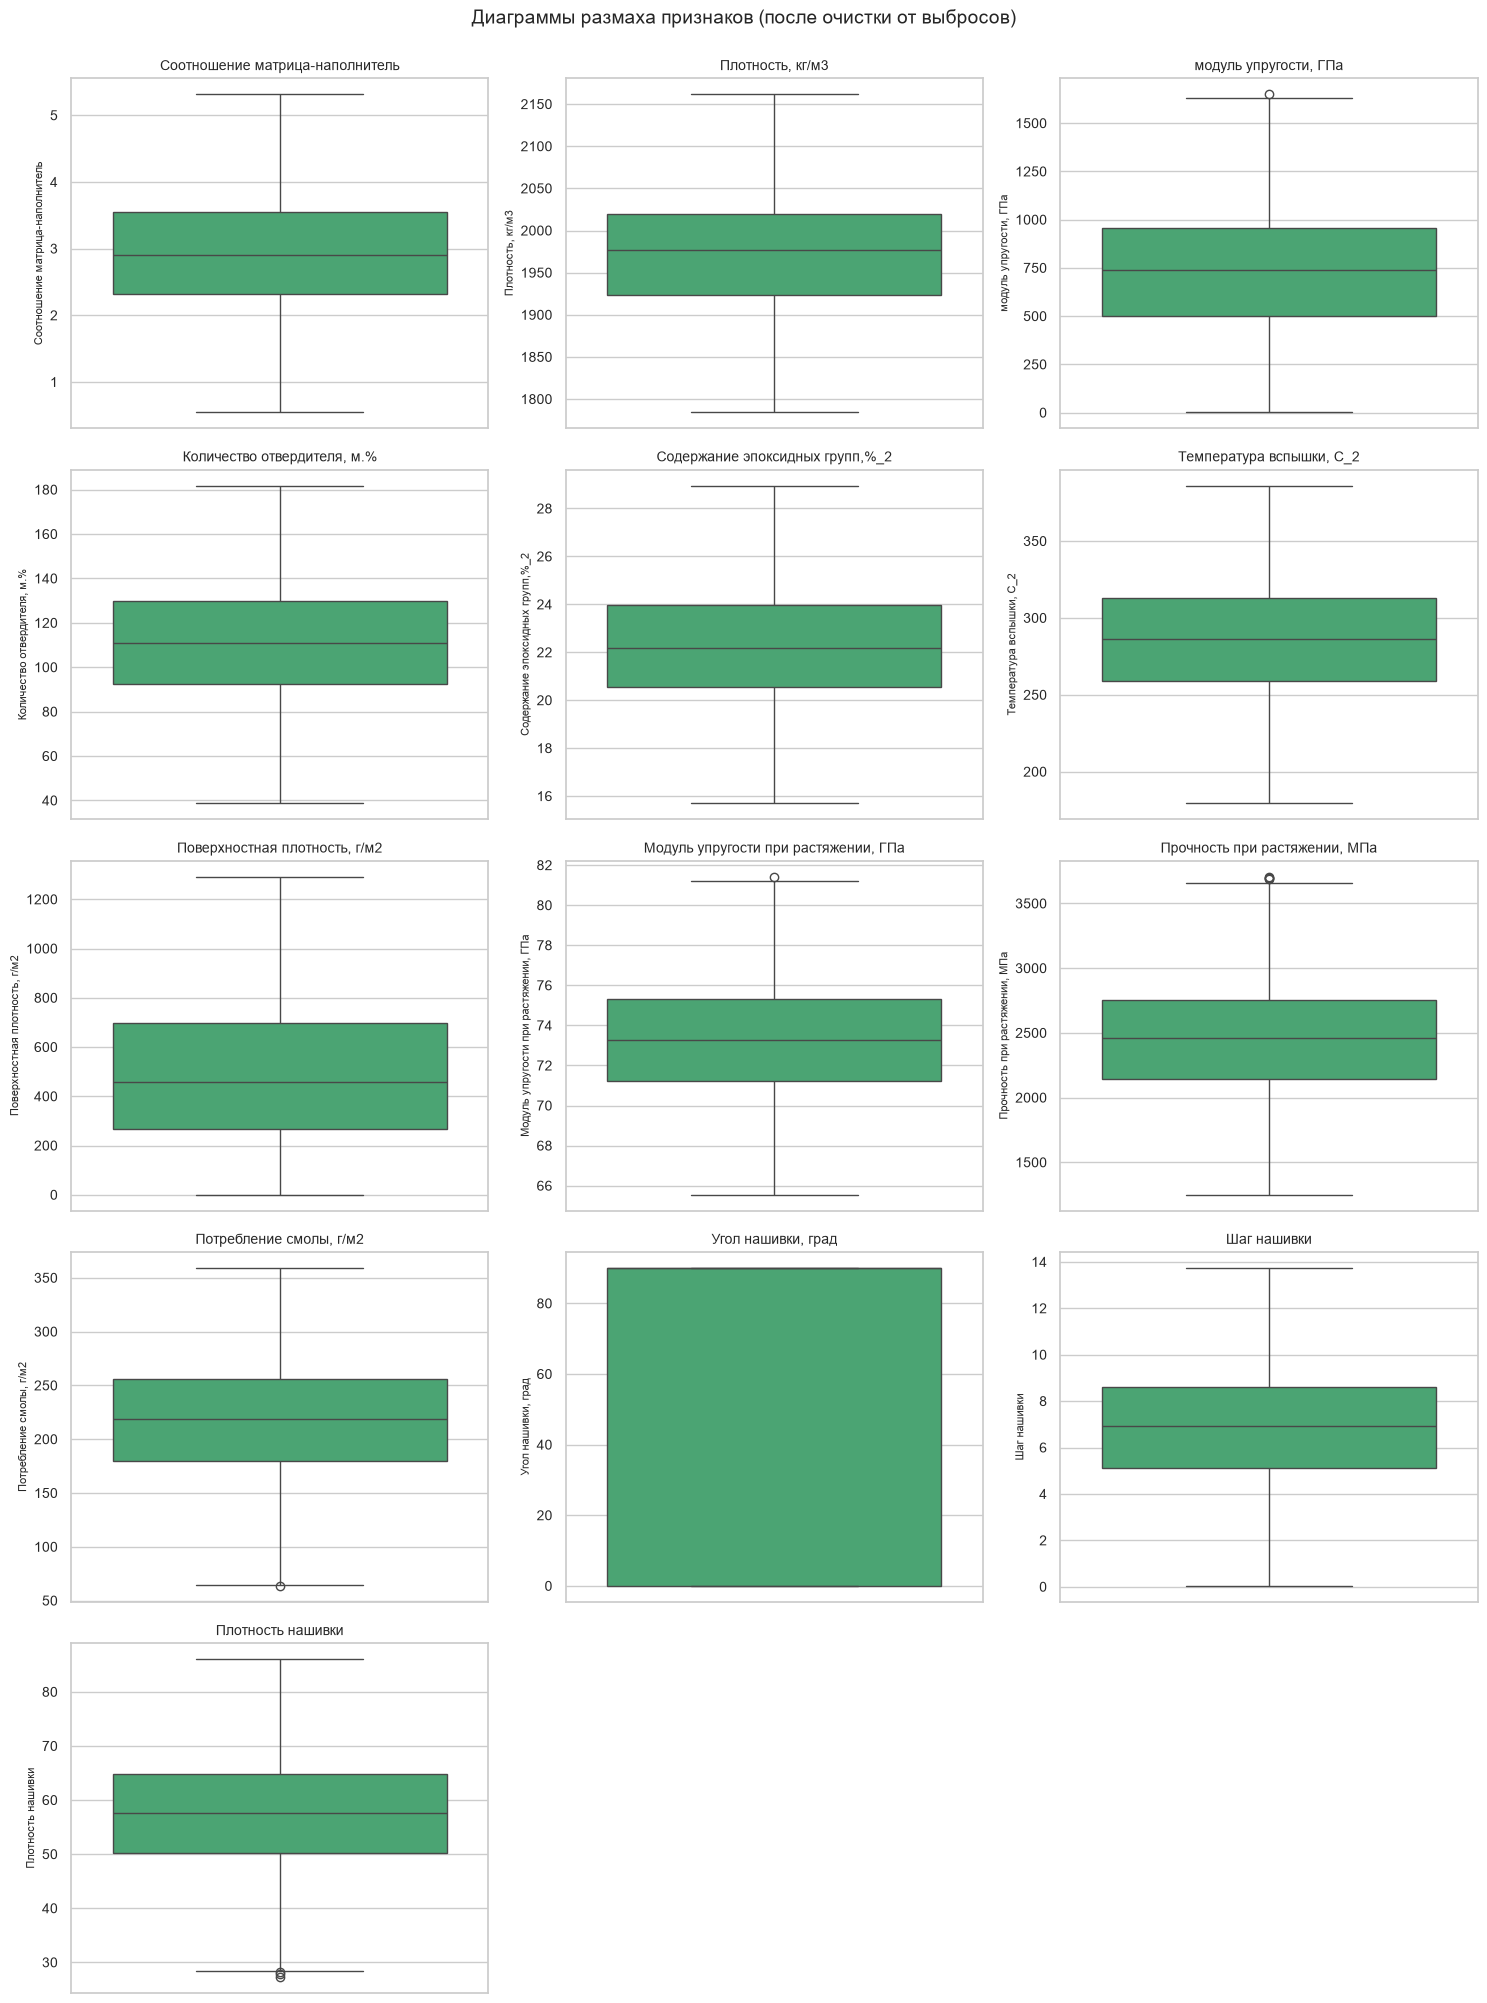

In [12]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color="mediumseagreen")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel(col, fontsize=8)

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Диаграммы размаха признаков (после очистки от выбросов)", fontsize=14, y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "boxplots_after_cleaning.png"), dpi=300, bbox_inches="tight")
plt.show()


## 5. Нормализация методом MinMaxScaler

Масштабируем все признаки очищенного датасета в диапазон [0, 1] с помощью
`MinMaxScaler`. Сравниваем гистограммы и таблицу минимумов/максимумов до и
после нормализации.

In [13]:
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df_clean),
    columns=df_clean.columns,
    index=df_clean.index,
)

minmax_before_after = pd.DataFrame({
    "минимум до": df_clean.min(),
    "максимум до": df_clean.max(),
    "минимум после": df_normalized.min(),
    "максимум после": df_normalized.max(),
})
minmax_before_after.to_csv(os.path.join(FIGURES_DIR, "minmax_before_after.csv"), encoding="utf-8-sig")
minmax_before_after


,минимум до,максимум до,минимум после,максимум после
Соотношение матрица-наполнитель,0.547391,5.314144,0.0,1.0
"Плотность, кг/м3",1784.482245,2161.565216,0.0,1.0
"модуль упругости, ГПа",2.436909,1649.415706,0.0,1.0
"Количество отвердителя, м.%",38.668500,181.828448,0.0,1.0
"Содержание эпоксидных групп,%_2",15.695894,28.955094,0.0,1.0
"Температура вспышки, С_2",179.374391,386.067992,0.0,1.0
"Поверхностная плотность, г/м2",0.603740,1291.340115,0.0,1.0
"Модуль упругости при растяжении, ГПа",65.553336,81.417126,0.0,1.0
"Прочность при растяжении, МПа",1250.392802,3705.672523,0.0,1.0
"Потребление смолы, г/м2",63.685698,359.052220,0.0,1.0


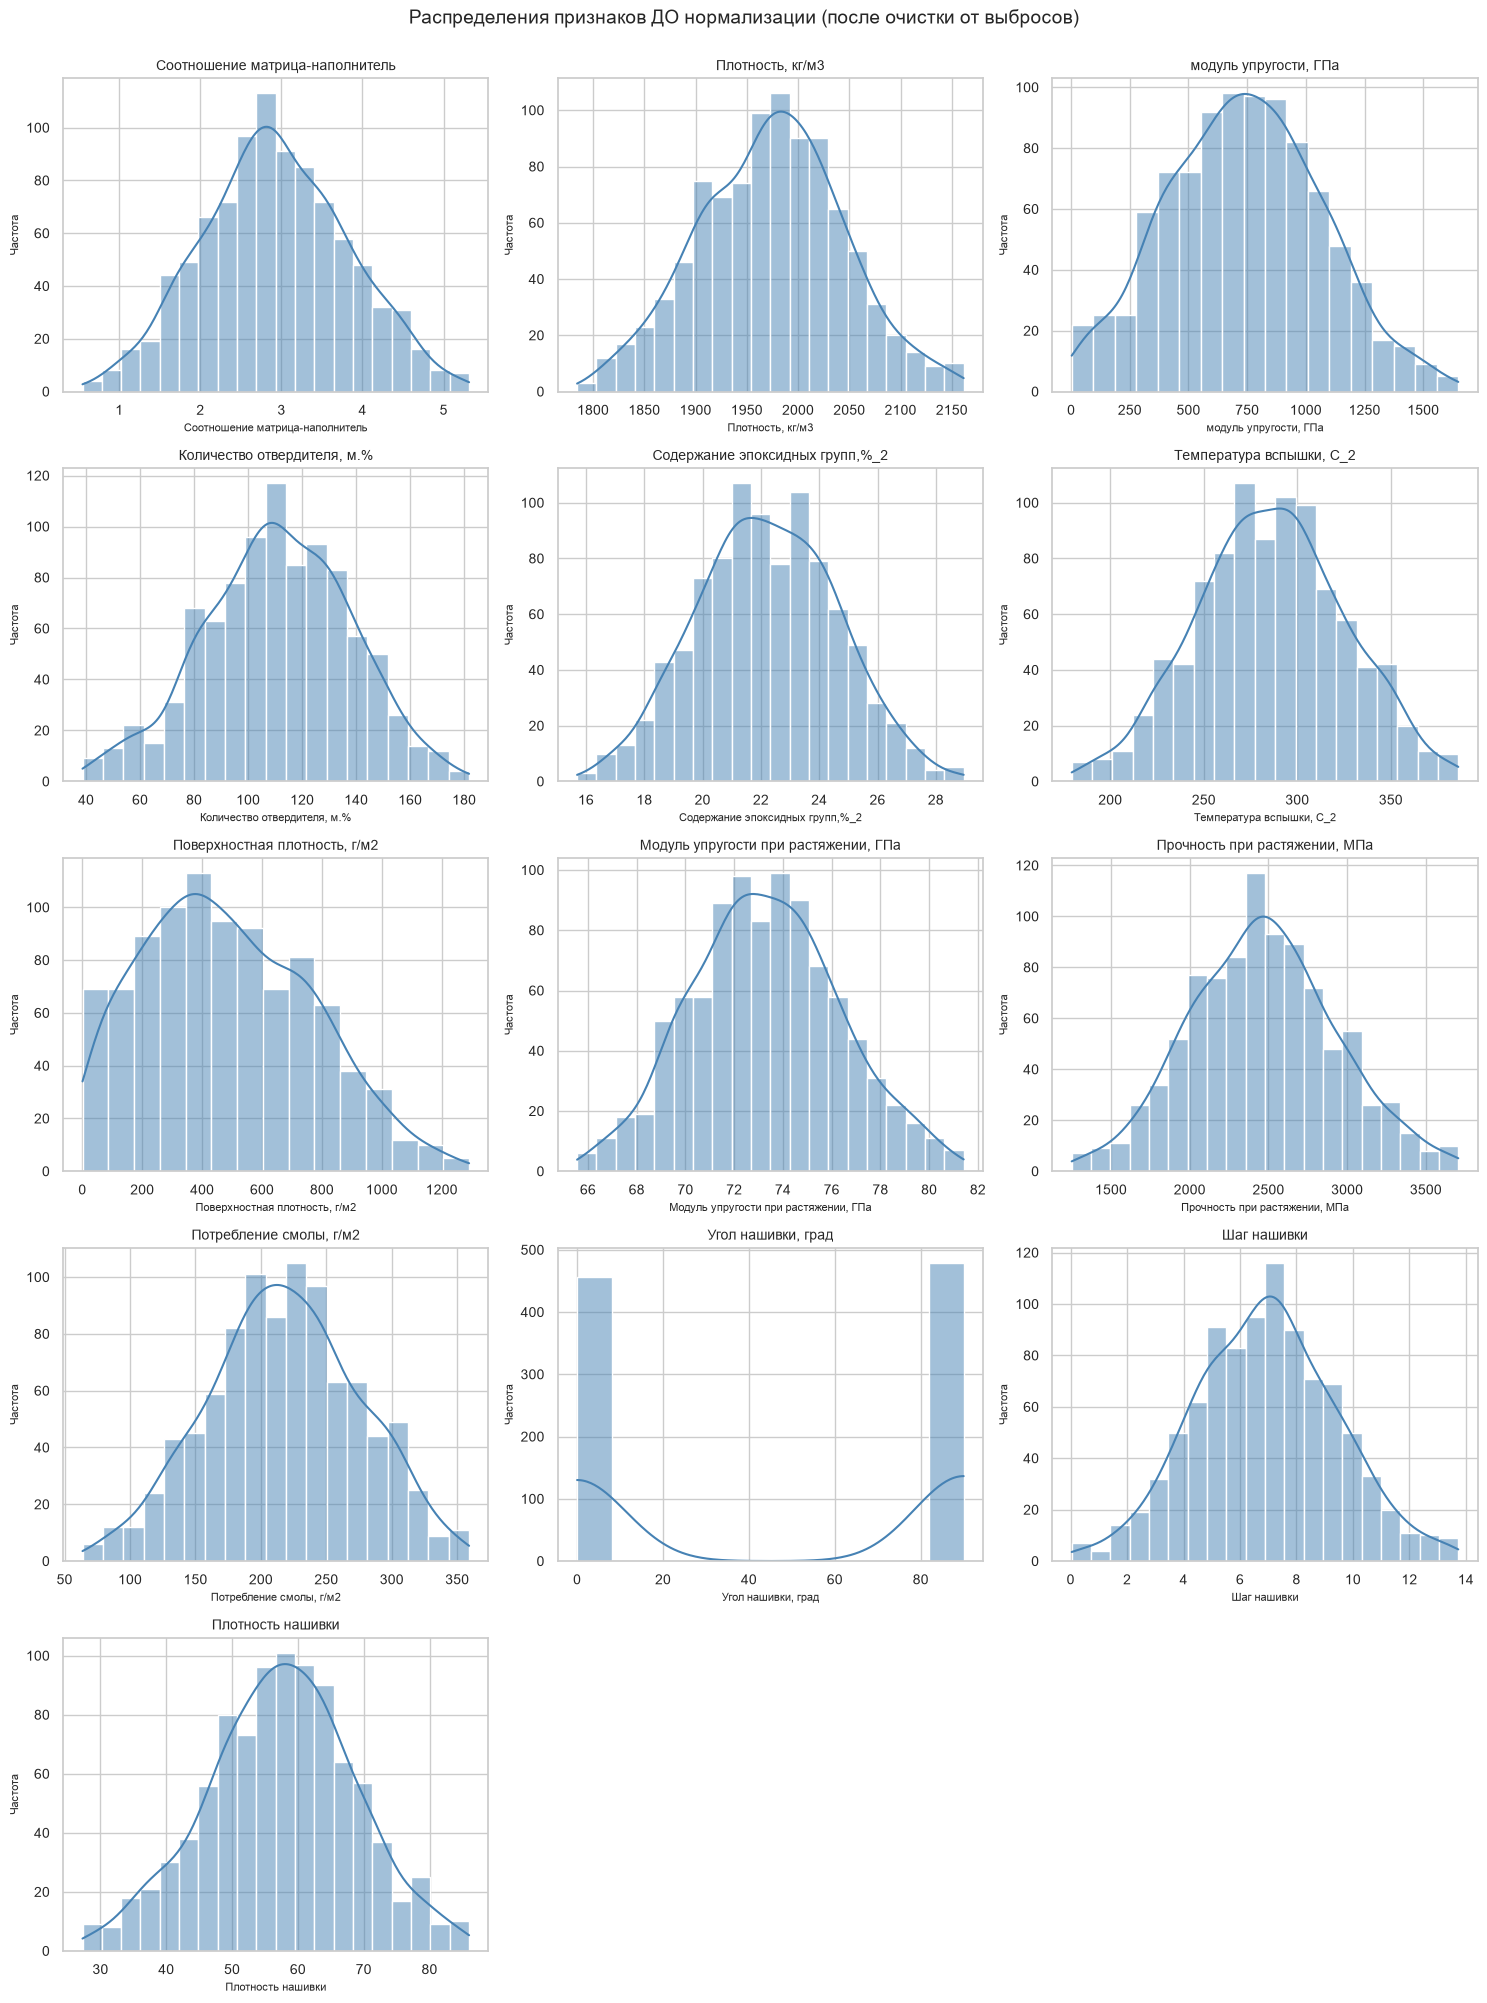

In [14]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color="steelblue", label="До нормализации", alpha=0.5)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel("Частота", fontsize=8)

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Распределения признаков ДО нормализации (после очистки от выбросов)", fontsize=14, y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "histograms_before_normalization.png"), dpi=300, bbox_inches="tight")
plt.show()


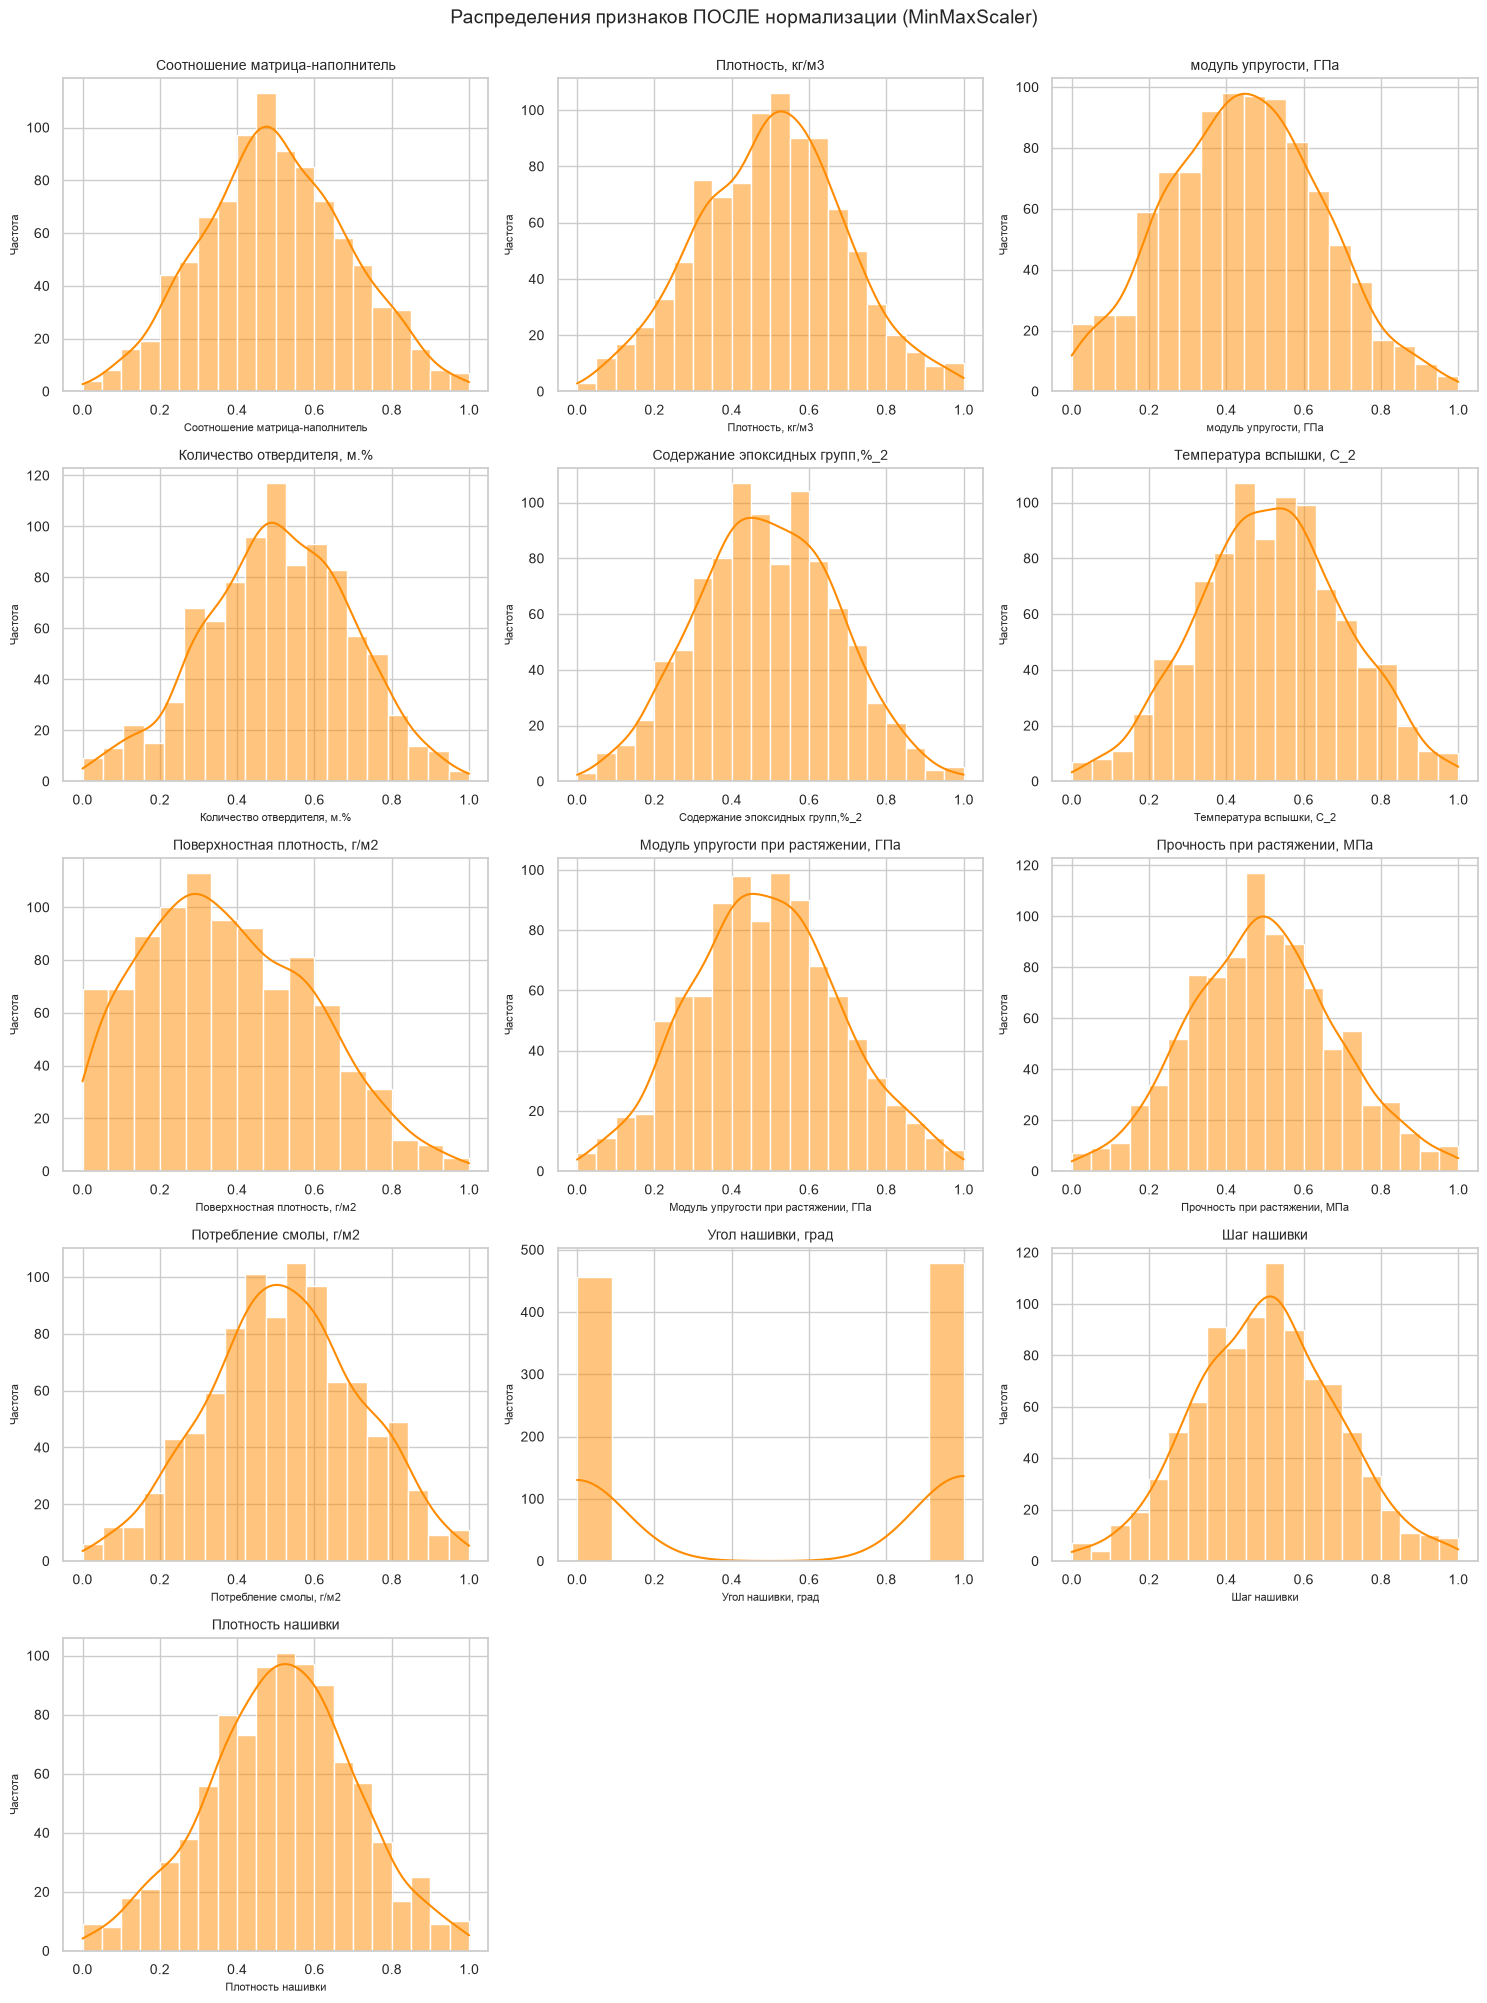

In [15]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df_normalized[col], kde=True, ax=axes[i], color="darkorange", label="После нормализации", alpha=0.5)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel("Частота", fontsize=8)

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Распределения признаков ПОСЛЕ нормализации (MinMaxScaler)", fontsize=14, y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "histograms_after_normalization.png"), dpi=300, bbox_inches="tight")
plt.show()


## 6. Сохранение обработанных данных

Сохраняем очищенный (но ещё не нормализованный) датасет и нормализованный
датасет в `data/processed/`.

In [16]:
clean_path = os.path.join(PROCESSED_DIR, "data_clean.csv")
normalized_path = os.path.join(PROCESSED_DIR, "data_normalized.csv")

df_clean.to_csv(clean_path, encoding="utf-8-sig")
df_normalized.to_csv(normalized_path, encoding="utf-8-sig")

print(f"Очищенный датасет сохранён: {clean_path}, размер {df_clean.shape}")
print(f"Нормализованный датасет сохранён: {normalized_path}, размер {df_normalized.shape}")


Очищенный датасет сохранён: ../data/processed\data_clean.csv, размер (936, 13)
Нормализованный датасет сохранён: ../data/processed\data_normalized.csv, размер (936, 13)


## Выводы

- Исходные файлы объединены по индексу через INNER JOIN, пропусков и
  дубликатов в объединённом датасете не обнаружено.
- Рассчитана описательная статистика по всем 13 признакам.
- Построены гистограммы, boxplot-ы, pairplot и тепловая карта корреляций.
- Методом IQR (1.5·IQR) обнаружены и удалены выбросы.
- Признаки нормализованы методом MinMaxScaler в диапазон [0, 1].
- Итоговые датасеты сохранены в `data/processed/data_clean.csv` и
  `data/processed/data_normalized.csv` для использования в следующих блоках
  ВКР (построение моделей машинного обучения).

## 7. Анализ структуры исходных данных

Во всех предыдущих блоках ни одна модель не превзошла наивный baseline.
Чтобы понять причину, проверяем, есть ли в самих данных закономерности,
которые в принципе можно выучить. Анализ выполняется на объединённой таблице
**до** удаления выбросов (1023 строки, индексы 0–1022); предыдущие разделы
ноутбука не изменялись.

In [17]:
from itertools import product

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import r2_score
from sklearn.model_selection import (GroupKFold, KFold, LeaveOneOut,
                                     cross_val_predict, cross_val_score)
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
df_full = df_bp.join(df_nup, how="inner")  # объединённая таблица до очистки
assert df_full.shape == (1023, 13)
assert (df_full.index == np.arange(1023)).all()  # позиция строки = индекс

TARGETS = ["Модуль упругости при растяжении, ГПа", "Прочность при растяжении, МПа"]
FEATURES = [c for c in df_full.columns if c not in TARGETS]
DENSITY = "Поверхностная плотность, г/м2"
ANGLE, STEP, PITCH = df_nup.columns
N_EXP = 23   # строки 0–22 X_bp
N_PLAN = 40  # строки 0–39 X_nup

print("Число признаков:", len(FEATURES))
print("Целевые переменные:", TARGETS)


Число признаков: 11
Целевые переменные: ['Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа']


### 7.1 Строки 0–22 таблицы X_bp: экспериментальные данные

Сравниваем число уникальных значений в каждом столбце X_bp для первых
23 строк и для остальных 1000 строк.

In [18]:
bp_exp = df_bp.iloc[:N_EXP]
bp_gen = df_bp.iloc[N_EXP:]

uniq = pd.DataFrame({
    f"Уникальных значений, строки 0–22 (n={len(bp_exp)})": bp_exp.nunique(),
    f"Уникальных значений, строки 23–1022 (n={len(bp_gen)})": bp_gen.nunique(),
})
display(uniq)


,"Уникальных значений, строки 0–22 (n=23)","Уникальных значений, строки 23–1022 (n=1000)"
Соотношение матрица-наполнитель,14,1000
"Плотность, кг/м3",13,1000
"модуль упругости, ГПа",20,1000
"Количество отвердителя, м.%",5,1000
"Содержание эпоксидных групп,%_2",4,1000
"Температура вспышки, С_2",3,1000
"Поверхностная плотность, г/м2",4,1000
"Модуль упругости при растяжении, ГПа",4,1000
"Прочность при растяжении, МПа",4,1000
"Потребление смолы, г/м2",3,1000


В строках 0–22 столбцы «Модуль упругости при растяжении», «Прочность при
растяжении» и «Потребление смолы» принимают всего 4, 4 и 3 различных
значения, «Поверхностная плотность» — 4. Ряд других столбцов тоже содержит
повторы: «Количество отвердителя» — 5 уникальных значений на 23 строки,
«Содержание эпоксидных групп» — 4, «Температура вспышки» — 3. В строках
23–1022 каждое значение в каждом столбце уникально (1000 из 1000).
Группируем первые 23 строки по «Поверхностной плотности».

In [19]:
DEPENDENT = ["Модуль упругости при растяжении, ГПа",
             "Прочность при растяжении, МПа",
             "Потребление смолы, г/м2"]

grouped = bp_exp.groupby(DENSITY)
materials = grouped[DEPENDENT].first()
materials.insert(0, "Число строк", grouped.size())
materials["Индексы строк X_bp"] = (
    pd.Series(bp_exp.index, index=bp_exp[DENSITY])
    .groupby(level=0).agg(lambda s: ", ".join(map(str, s))))

# внутри каждой группы три показателя не меняются вообще
assert (grouped[DEPENDENT].nunique() == 1).all().all()
assert materials["Число строк"].sum() == N_EXP
assert len(materials[DEPENDENT].drop_duplicates()) == len(materials) == 4

display(materials)
print(f"Комбинаций (модуль, прочность, расход смолы) среди 23 строк: "
      f"{len(materials[DEPENDENT].drop_duplicates())}; "
      f"значений поверхностной плотности: {bp_exp[DENSITY].nunique()}")


,Число строк,"Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2",Индексы строк X_bp
"Поверхностная плотность, г/м2",,,,,
210.0,9,70.000000,3000.000000,220.0,"0, 1, 2, 3, 4, 5, 6, 15, 16"
380.0,4,75.000000,1800.000000,120.0,"7, 8, 17, 18"
470.0,5,73.333333,2455.555556,220.0,"12, 13, 14, 21, 22"
1010.0,5,78.000000,2000.000000,300.0,"9, 10, 11, 19, 20"


Комбинаций (модуль, прочность, расход смолы) среди 23 строк: 4; значений поверхностной плотности: 4


Три показателя («Модуль упругости при растяжении», «Прочность при
растяжении», «Потребление смолы») определяются **только** поверхностной
плотностью: в каждой из 4 групп (9, 4, 5 и 5 строк) они строго постоянны,
хотя остальные параметры (соотношение матрица-наполнитель, плотность,
модуль упругости наполнителя и др.) между строками одной группы различаются.
Это не 23 независимых измерения, а 4 материала, для каждого из которых
несколько раз записаны одни и те же свойства.

Проверяем, совпадают ли повторяющиеся значения 738.7368, 111.86, 22.27 и
284.62 со средним или медианой своего столбца (по всем 1023 строкам X_bp).

In [20]:
REPEATED = {
    "модуль упругости, ГПа": 738.7368,
    "Количество отвердителя, м.%": 111.86,
    "Содержание эпоксидных групп,%_2": 22.27,
    "Температура вспышки, С_2": 284.62,
}

rows = []
for col, approx in REPEATED.items():
    counts = bp_exp[col].value_counts()
    repeated_values = counts[counts > 1].index  # значения, встречающиеся более 1 раза
    value = repeated_values[np.argmin(np.abs(repeated_values - approx))]
    assert abs(value - approx) < 0.01
    mean, median = df_bp[col].mean(), df_bp[col].median()
    rows.append({
        "Столбец": col,
        "Повторяющееся значение": value,
        "Повторов в строках 0–22": int((bp_exp[col] == value).sum()),
        "Повторов в строках 23–1022": int((bp_gen[col] == value).sum()),
        "Среднее столбца": mean,
        "Медиана столбца": median,
        "Откл. от среднего, %": (value - mean) / mean * 100,
        "Откл. от медианы, %": (value - median) / median * 100,
        "Совпадает со средним/медианой": bool(
            np.isclose(value, mean, rtol=1e-6) or np.isclose(value, median, rtol=1e-6)),
    })
repeated_table = pd.DataFrame(rows).set_index("Столбец")
display(repeated_table.round(4))

print("Все значения, повторяющиеся в строках 0–22 (значение: число повторов):")
for col in list(REPEATED)[1:]:
    counts = bp_exp[col].value_counts()
    print(f"  {col}: {counts[counts > 1].round(4).to_dict()}")


,Повторяющееся значение,Повторов в строках 0–22,Повторов в строках 23–1022,Среднее столбца,Медиана столбца,"Откл. от среднего, %","Откл. от медианы, %",Совпадает со средним/медианой
Столбец,,,,,,,,
"модуль упругости, ГПа",738.7368,4,0,739.9232,739.6643,-0.1603,-0.1254,False
"Количество отвердителя, м.%",111.8600,8,0,110.5708,110.5648,1.1660,1.1714,False
"Содержание эпоксидных групп,%_2",22.2679,9,0,22.2444,22.2307,0.1055,0.1669,False
"Температура вспышки, С_2",284.6154,10,0,285.8822,285.8968,-0.4431,-0.4482,False


Все значения, повторяющиеся в строках 0–22 (значение: число повторов):
  Количество отвердителя, м.%: {129.0: 12, 111.86: 8}
  Содержание эпоксидных групп,%_2: {21.25: 12, 22.2678571428571: 9}
  Температура вспышки, С_2: {300.0: 12, 284.615384615384: 10}


**Совпадение не подтверждается.** Повторяющиеся значения лишь близки к
центру распределения: отклонение от среднего составляет от 0.11 % до 1.17 %
по модулю, от медианы — от 0.13 % до 1.17 %, но точного равенства нет ни в
одном столбце. Поэтому утверждать, что они получены подстановкой среднего или
медианы, нельзя. Все четыре значения встречаются только в строках 0–22
(4–10 повторов), в строках 23–1022 их нет. Кроме них, в трёх столбцах
повторяются ещё округлые значения 129, 21.25 и 300 (по 12 раз в тех же
строках 0–22).

### 7.2 Строки 0–39 таблицы X_nup: план эксперимента

Проверяем, образуют ли первые 40 строк X_nup факторный план
«угол × шаг × плотность нашивки».

In [21]:
plan = df_nup.iloc[:N_PLAN]
zero_rows = plan[(plan == 0).all(axis=1)]
plan_main = plan.drop(zero_rows.index)

expected = set(product([0, 90], [4, 5, 7, 9, 10], [47, 57, 60, 70]))
actual = set(map(tuple, plan_main.to_numpy().tolist()))

print("Уникальные значения в строках 0–39:")
for col in plan.columns:
    print(f"  {col}: {sorted(plan[col].unique().tolist())}")
print("Строки, целиком состоящие из нулей (индексы):", zero_rows.index.tolist())
print("Ожидаемых комбинаций плана 2 × 5 × 4:", len(expected))
print("Присутствует комбинаций:", len(actual & expected))
print("Отсутствует:", sorted(expected - actual))
print("Лишних комбинаций вне плана:", sorted(actual - expected))
print("Повторяющихся комбинаций:", int(plan_main.duplicated().sum()))
print("Строки упорядочены по (угол, шаг, плотность):",
      plan_main.equals(plan_main.sort_values([ANGLE, STEP, PITCH])))

display(pd.crosstab([plan_main[ANGLE], plan_main[STEP]], plan_main[PITCH])
        .rename_axis(index=["Угол нашивки, град", "Шаг нашивки"],
                     columns="Плотность нашивки"))

rest_nup = df_full[[ANGLE, STEP, PITCH]].iloc[N_PLAN:]
print("Строки 40–1022 (n=%d): уникальных значений" % len(rest_nup))
print(rest_nup.nunique().to_string())
print("Значения угла в строках 40–1022:", rest_nup[ANGLE].value_counts().to_dict())


Уникальные значения в строках 0–39:
  Угол нашивки, град: [0, 90]
  Шаг нашивки: [0.0, 4.0, 5.0, 7.0, 9.0, 10.0]
  Плотность нашивки: [0.0, 47.0, 57.0, 60.0, 70.0]
Строки, целиком состоящие из нулей (индексы): [19]
Ожидаемых комбинаций плана 2 × 5 × 4: 40
Присутствует комбинаций: 39
Отсутствует: [(0, 4, 47)]
Лишних комбинаций вне плана: []
Повторяющихся комбинаций: 0
Строки упорядочены по (угол, шаг, плотность): True


Плотность нашивки               47.0  57.0  60.0  70.0
Угол нашивки, град Шаг нашивки                        
0                  4.0             0     1     1     1
                   5.0             1     1     1     1
                   7.0             1     1     1     1
                   9.0             1     1     1     1
                   10.0            1     1     1     1
90                 4.0             1     1     1     1
                   5.0             1     1     1     1
                   7.0             1     1     1     1
                   9.0             1     1     1     1
                   10.0            1     1     1     1

Строки 40–1022 (n=983): уникальных значений
Угол нашивки, град      2
Шаг нашивки           983
Плотность нашивки     983
Значения угла в строках 40–1022: {0: 500, 90: 483}


Строки 0–39 — это перебор сетки параметров: 39 из 40 комбинаций плана
«угол 0/90 × шаг 4, 5, 7, 9, 10 × плотность 47, 57, 60, 70» присутствуют ровно
по одному разу и упорядочены по углу, шагу и плотности; отсутствует только
комбинация (0°, 4, 47). Кроме того, строка 19 целиком состоит из нулей.
Лишних комбинаций вне сетки нет. Начиная со строки 40 значения шага и
плотности нашивки уникальны в каждой строке (непрерывные числа), а угол
по-прежнему принимает только значения 0 и 90.

Проверяем, могут ли эти значения быть измерениями, относящимися к
соответствующим строкам X_bp: если бы нашивка была характеристикой образца,
образцы одного материала имели бы согласованные параметры нашивки.

In [22]:
link = bp_exp[[DENSITY] + DEPENDENT].join(plan)
link["комбинация нашивки"] = link[[ANGLE, STEP, PITCH]].apply(
    lambda r: "/".join(f"{v:g}" for v in r), axis=1)
per_material = link.groupby(DENSITY).agg(
    **{"Число строк": ("комбинация нашивки", "size"),
       "Различных комбинаций нашивки": ("комбинация нашивки", "nunique"),
       "Различных значений модуля упругости": (DEPENDENT[0], "nunique")})
display(per_material)


,Число строк,Различных комбинаций нашивки,Различных значений модуля упругости
"Поверхностная плотность, г/м2",,,
210.0,9,9,1
380.0,4,4,1
470.0,5,5,1
1010.0,5,5,1


В пределах одного материала (один и тот же модуль упругости) каждая строка
получает **свою** комбинацию нашивки (число комбинаций равно числу строк),
а свойства при этом не меняются. Параметры нашивки в строках 0–39 X_nup —
это однократный перебор сетки плана, а не измерения, связанные с
конкретными образцами X_bp; их сопоставление со строками X_bp возникает
только из-за объединения по номеру строки.

### 7.3 Строки с 40-й: есть ли связь признаков с целевыми переменными

Берём строки 40–1022 объединённой таблицы (после экспериментальной части и
сетки нашивки). Для каждой целевой переменной вычисляем:

- максимальную по модулю корреляцию Пирсона с 11 признаками;
- взаимную информацию `mutual_info_regression` каждого из 11 признаков с
  целью и сравниваем её с **референсом чистого шума** — 11 случайных
  признаков `N(0, 1)`, повторённых 30 раз (330 значений);
- R² модели RandomForest (200 деревьев) при 5-блочной кросс-валидации, рядом —
  `DummyRegressor` и RandomForest на чистом шуме.

In [23]:
data_part = df_full.iloc[N_PLAN:]  # строки 40–1022
X_part = data_part[FEATURES]
n_part = len(data_part)
print(f"Наблюдений: {n_part}, признаков: {X_part.shape[1]}")
print(f"Порог значимости |r| (5 %, без поправки на множественные сравнения): "
      f"{1.96 / np.sqrt(n_part):.4f}")

N_NOISE = 30
rng = np.random.default_rng(RANDOM_STATE)
noise_sets = [rng.normal(size=X_part.shape) for _ in range(N_NOISE)]

cv5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)

summary_rows, mi_results = [], {}
for target in TARGETS:
    y = data_part[target]
    corr = X_part.corrwith(y)
    mi_data = pd.Series(
        mutual_info_regression(X_part, y, random_state=RANDOM_STATE), index=FEATURES)
    mi_noise = np.concatenate([
        mutual_info_regression(Xn, y, random_state=RANDOM_STATE) for Xn in noise_sets])
    r2_rf = cross_val_score(rf, X_part, y, cv=cv5, scoring="r2")
    r2_dummy = cross_val_score(DummyRegressor(), X_part, y, cv=cv5, scoring="r2")
    r2_rf_noise = cross_val_score(rf, noise_sets[0], y, cv=cv5, scoring="r2")
    mi_results[target] = (mi_data, mi_noise)
    summary_rows.append({
        "Целевая переменная": target,
        "Число наблюдений": n_part,
        "Макс. |корреляция|": corr.abs().max(),
        "Признак с макс. |корреляцией|": corr.abs().idxmax(),
        "MI макс. (данные)": mi_data.max(),
        "Признак с макс. MI": mi_data.idxmax(),
        "MI среднее (данные)": mi_data.mean(),
        "MI среднее (шум)": mi_noise.mean(),
        "MI 95-й перцентиль (шум)": np.percentile(mi_noise, 95),
        "MI макс. (шум)": mi_noise.max(),
        "R² RandomForest, CV (среднее)": r2_rf.mean(),
        "R² RandomForest, CV (стд)": r2_rf.std(),
        "R² DummyRegressor, CV (среднее)": r2_dummy.mean(),
        "R² RandomForest на шуме, CV (среднее)": r2_rf_noise.mean(),
    })

data_structure = pd.DataFrame(summary_rows).set_index("Целевая переменная")
data_structure.round(4).to_csv(
    os.path.join(FIGURES_DIR, "data_structure.csv"), encoding="utf-8-sig")
display(data_structure.round(4).T)


Наблюдений: 983, признаков: 11
Порог значимости |r| (5 %, без поправки на множественные сравнения): 0.0625


Целевая переменная,"Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа"
Число наблюдений,983,983
Макс. |корреляция|,0.0889,0.0707
Признак с макс. |корреляцией|,"Количество отвердителя, м.%","Плотность, кг/м3"
MI макс. (данные),0.0181,0.0508
Признак с макс. MI,"модуль упругости, ГПа",Соотношение матрица-наполнитель
MI среднее (данные),0.0038,0.0075
MI среднее (шум),0.0098,0.0088
MI 95-й перцентиль (шум),0.0389,0.0361
MI макс. (шум),0.0774,0.0855
"R² RandomForest, CV (среднее)",-0.0949,-0.0409


In [24]:
mi_table = pd.DataFrame({t: mi_results[t][0] for t in TARGETS}).round(4)
mi_table.index.name = "Признак"
display(mi_table)


,"Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа"
Признак,,
Соотношение матрица-наполнитель,0.0000,0.0508
"Плотность, кг/м3",0.0098,0.0000
"модуль упругости, ГПа",0.0181,0.0000
"Количество отвердителя, м.%",0.0000,0.0000
"Содержание эпоксидных групп,%_2",0.0000,0.0157
"Температура вспышки, С_2",0.0000,0.0000
"Поверхностная плотность, г/м2",0.0000,0.0000
"Потребление смолы, г/м2",0.0025,0.0000
"Угол нашивки, град",0.0116,0.0166


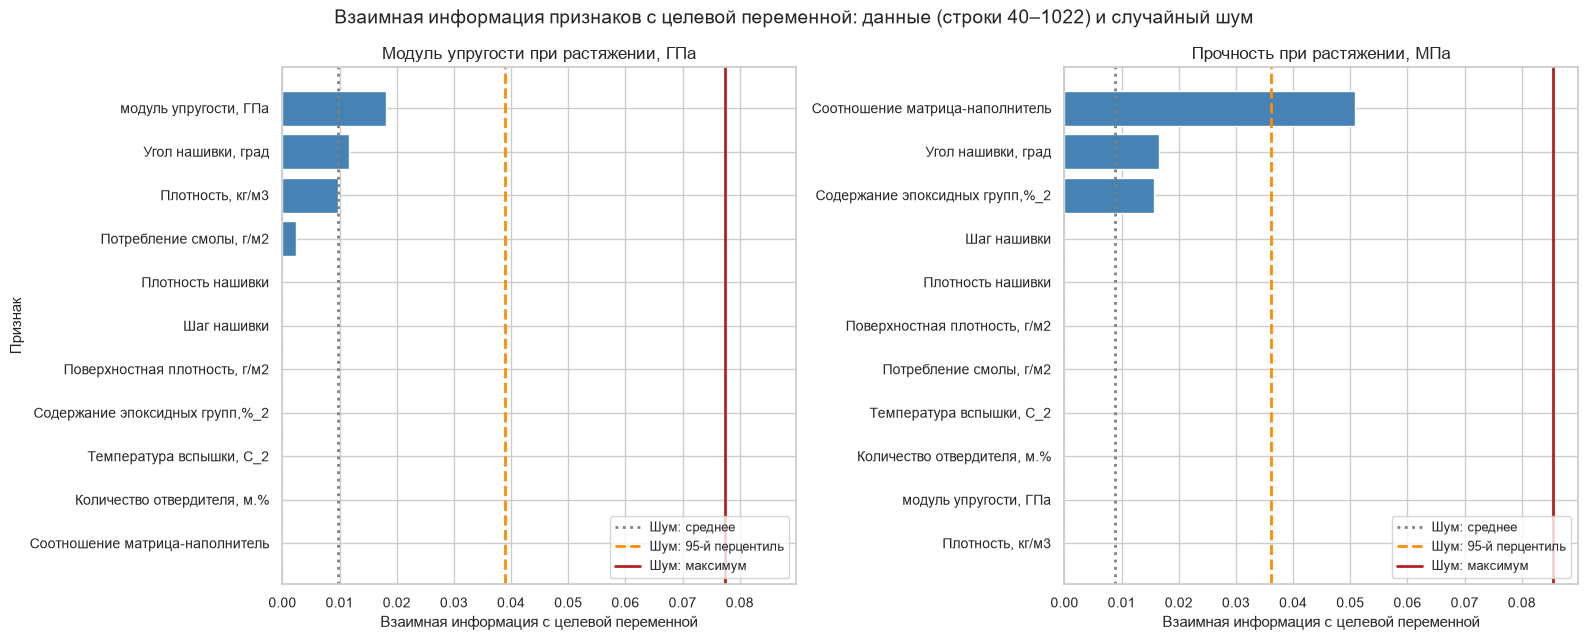

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True)
for ax, target in zip(axes, TARGETS):
    mi_data, mi_noise = mi_results[target]
    mi_sorted = mi_data.sort_values()
    ax.barh(mi_sorted.index, mi_sorted.values, color="steelblue")
    ax.axvline(mi_noise.mean(), color="gray", linestyle=":", linewidth=2,
               label="Шум: среднее")
    ax.axvline(np.percentile(mi_noise, 95), color="darkorange", linestyle="--",
               linewidth=2, label="Шум: 95-й перцентиль")
    ax.axvline(mi_noise.max(), color="firebrick", linestyle="-", linewidth=2,
               label="Шум: максимум")
    ax.set_title(target, fontsize=12)
    ax.set_xlabel("Взаимная информация с целевой переменной")
    ax.legend(loc="lower right", fontsize=9)
axes[0].set_ylabel("Признак")
fig.suptitle("Взаимная информация признаков с целевой переменной: данные "
             "(строки 40–1022) и случайный шум", fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "mutual_info_vs_noise.png"), dpi=300, bbox_inches="tight")
plt.show()


**Результаты (строки 40–1022, 983 наблюдения):**

- Максимальная по модулю корреляция с 11 признаками — 0.089 (модуль) и 0.071
  (прочность). Порог значимости для одного признака при n = 983 равен 0.0625;
  при 11 независимых признаках вероятность хотя бы одного превышения
  только из-за случайности составляет около 43 %, то есть такие значения
  находятся на уровне шума.
- Взаимная информация с модулем упругости: максимум 0.018
  («модуль упругости, ГПа» наполнителя), что ниже 95-го перцентиля шума
  (0.039); среднее по признакам (0.004) ниже среднего по шуму (0.010). С
  прочностью: максимум 0.051 («Соотношение матрица-наполнитель») —
  выше 95-го перцентиля шума (0.036), но ниже максимума шума (0.086);
  среднее по признакам (0.008) ниже среднего по шуму (0.009).
- RandomForest при 5-блочной кросс-валидации: R² = −0.095 ± 0.051 (модуль)
  и −0.041 ± 0.024 (прочность); `DummyRegressor` даёт −0.007 и −0.005, а
  RandomForest на чистом шуме — −0.069 и −0.050. На реальных признаках модель
  не лучше, чем на случайных числах.

Таким образом, в части данных, начиная с 40-й строки, признаки не содержат
информации о целевых переменных сверх уровня шума.

### 7.4 Только 23 экспериментальные строки: запоминание или обобщение

Оставляем 23 строки 0–22 и единственный входной признак — «Поверхностная
плотность». Модель — `DecisionTreeRegressor` (без ограничения глубины).
Проверяем двумя схемами:

- **LeaveOneOut** — на каждом шаге из обучения убирается одна строка;
  остальные строки того же материала остаются в обучающей выборке;
- **GroupKFold** (4 блока) с группировкой по типу материала — в тестовый
  блок целиком попадает один из 4 материалов, которого модель не видела.

R² считается по объединённым предсказаниям всех блоков. Для сравнения —
`DummyRegressor` (среднее по обучающей части) в тех же схемах.

In [26]:
exp = df_full.iloc[:N_EXP]
x_exp = exp[[DENSITY]]
groups = exp[DENSITY].to_numpy()  # тип материала = значение поверхностной плотности

gkf = GroupKFold(n_splits=4)
assert all(len(set(groups[test])) == 1 for _, test in gkf.split(x_exp, groups=groups))

schemes = {"LeaveOneOut": (LeaveOneOut(), None),
           "GroupKFold по типу материала (4 группы)": (gkf, groups)}

tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
dummy = DummyRegressor()

rows, predictions = [], {}
for target in TARGETS:
    y = exp[target]
    rows.append({"Целевая переменная": target,
                 "Схема проверки": "Обучение на всех 23 строках (не валидация)",
                 "R² DecisionTree": tree.fit(x_exp, y).score(x_exp, y),
                 "R² DummyRegressor": dummy.fit(x_exp, y).score(x_exp, y)})
    predictions[target] = pd.DataFrame({"факт": y.to_numpy()}, index=exp.index)
    for name, (cv, grp) in schemes.items():
        pred_tree = cross_val_predict(tree, x_exp, y, cv=cv, groups=grp)
        pred_dummy = cross_val_predict(dummy, x_exp, y, cv=cv, groups=grp)
        predictions[target][name] = pred_tree
        rows.append({"Целевая переменная": target, "Схема проверки": name,
                     "R² DecisionTree": r2_score(y, pred_tree),
                     "R² DummyRegressor": r2_score(y, pred_dummy)})

real_rows_model = pd.DataFrame(rows)
real_rows_model.round(4).to_csv(
    os.path.join(FIGURES_DIR, "real_rows_model.csv"), index=False, encoding="utf-8-sig")
display(real_rows_model.round(4))


,Целевая переменная,Схема проверки,R² DecisionTree,R² DummyRegressor
0,"Модуль упругости при растяжении, ГПа",Обучение на всех 23 строках (не валидация),1.0000,0.0000
1,"Модуль упругости при растяжении, ГПа",LeaveOneOut,1.0000,-0.0930
2,"Модуль упругости при растяжении, ГПа",GroupKFold по типу материала (4 группы),-0.6313,-1.1089
3,"Прочность при растяжении, МПа",Обучение на всех 23 строках (не валидация),1.0000,0.0000
4,"Прочность при растяжении, МПа",LeaveOneOut,1.0000,-0.0930
5,"Прочность при растяжении, МПа",GroupKFold по типу материала (4 группы),-2.2935,-1.1041


In [27]:
for target in TARGETS:
    by_material = predictions[target].copy()
    by_material[DENSITY] = groups
    print(target)
    display(by_material.groupby(DENSITY).first().round(2)
            .rename(columns={"факт": "Факт",
                             "LeaveOneOut": "Прогноз LeaveOneOut",
                             "GroupKFold по типу материала (4 группы)":
                                 "Прогноз GroupKFold (материал не виден)"}))


Модуль упругости при растяжении, ГПа


,Факт,Прогноз LeaveOneOut,Прогноз GroupKFold (материал не виден)
"Поверхностная плотность, г/м2",,,
210.0,70.00,70.00,75.00
380.0,75.00,75.00,73.33
470.0,73.33,73.33,75.00
1010.0,78.00,78.00,73.33


Прочность при растяжении, МПа


,Факт,Прогноз LeaveOneOut,Прогноз GroupKFold (материал не виден)
"Поверхностная плотность, г/м2",,,
210.0,3000.00,3000.00,1800.00
380.0,1800.00,1800.00,2455.56
470.0,2455.56,2455.56,1800.00
1010.0,2000.00,2000.00,2455.56


**Результаты.** При обучении на всех 23 строках и при LeaveOneOut
R² = 1.0 для обоих показателей: дерево по одной поверхностной плотности
точно воспроизводит свойства, потому что для каждого из 4 материалов в
обучающей выборке остаются другие строки с теми же значениями. Это
запоминание известных материалов, а не обнаруженная закономерность.

Если же материал целиком исключён из обучения (GroupKFold по типу материала),
R² дерева отрицателен: −0.631 для модуля упругости и −2.294 для прочности.
Для модуля дерево лучше `DummyRegressor` (−1.109), для прочности —
хуже него (−1.104), но в обоих случаях результат хуже, чем прогноз среднего
по всем данным (R² = 0). В таблице прогнозов видно: на невиданном материале
дерево выдаёт значение одного из трёх оставшихся материалов. Итог:
модель запоминает 4 известных материала, но не обобщается на новый материал.
Число независимых наблюдений здесь равно 4 (а не 23), чего недостаточно
для выявления зависимости.

### 7.5 Вывод по структуре данных

Набор данных состоит из двух частей:

1. **Несколько реальных экспериментальных записей** — строки 0–22 X_bp
   (фактически 4 материала с постоянными свойствами) и строки 0–39 X_nup
   (перебор плана нашивки, не связанный со свойствами образцов).
2. **Данные, сгенерированные без зависимостей между переменными** — строки
   с 23-й в X_bp и с 40-й в X_nup: все значения уникальны и непрерывны, а
   взаимная информация, корреляции и кросс-валидация RandomForest не
   отличаются от результата на случайном шуме.

В экспериментальной части единственная зависимость — «Поверхностная
плотность → модуль, прочность, расход смолы» — выучивается только как
запоминание 4 материалов и не переносится на новый материал. В остальной
части связей нет. Это объясняет, почему ни одна модель (линейные, деревья,
ансамбли, нейронная сеть) не превзошла baseline в блоках 2–3: причина не в
выборе алгоритма или гиперпараметров, а в отсутствии предсказуемой
структуры в данных.